In [302]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import shutil
import string
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import losses

In [303]:
batch_size = 32
seed = 42
max_features = 10000
sequence_length = 250

train_data = pd.read_csv("/content/sample_data/train/train_subset.csv")
test_data = pd.read_csv("/content/sample_data/test/test.csv")

train_data["text"] = (train_data["Title"] + " " + train_data["Description"]).astype(str)
test_data["text"] = (test_data["Title"] + " " + test_data["Description"]).astype(str)

print(train_data.describe())

train_data = train_data.sample(frac=1, random_state=seed)

train_size = int(0.8 * len(train_data))
val_data = train_data[train_size:]
train_data = train_data[:train_size]

train_data["Class Index"] -= 1
val_data["Class Index"] -= 1
test_data["Class Index"] -= 1

raw_train_ds = tf.data.Dataset.from_tensor_slices((train_data["text"].values, train_data["Class Index"].values))
raw_val_ds = tf.data.Dataset.from_tensor_slices((val_data["text"].values, val_data["Class Index"].values))
raw_test_ds = tf.data.Dataset.from_tensor_slices((test_data["text"].values, test_data["Class Index"].values))

raw_train_ds = raw_train_ds.batch(batch_size)
raw_val_ds = raw_val_ds.batch(batch_size)
raw_test_ds = raw_test_ds.batch(batch_size)


for text_batch, label_batch in raw_train_ds.take(1):
    print("text_batch shape:", text_batch.shape)  # (32,)
    print("label_batch shape:", label_batch.shape)
    print("text_batch:", text_batch)


         Unnamed: 0   Class Index
count  12000.000000  12000.000000
mean    6013.239333      2.500000
std     3488.139367      1.118081
min        0.000000      1.000000
25%     2999.750000      1.750000
50%     5999.500000      2.500000
75%     8999.250000      3.250000
max    12780.000000      4.000000
text_batch shape: (32,)
label_batch shape: (32,)
text_batch: tf.Tensor(
[b' #39;Jackal aide #39; in case 2 acquittal BERLIN, Germany -- A German court has acquitted Johannes Weinrich, said to be the right-hand man of international guerrilla  quot;Carlos the Jackal, quot; of charges that he took part in a deadly series of bombings in France in the early 1980s.'
 b'Costco faces sex discrimination suit An assistant manager at one of Costco #39;s Colorado warehouses filed a sex discrimination lawsuit against the Issaquah-based company yesterday, alleging that it overlooks women for promotion. '
 b'One dead, six missing after Maoist attack More than 1000 Maoist rebels stormed a district hea

In [304]:
def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  stripped_html = tf.strings.regex_replace(lowercase, '', ' ')
  return tf.strings.regex_replace(stripped_html,
                                  '[%s]' % re.escape(string.punctuation),
                                  '')

In [305]:
vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length)

In [306]:
train_text = raw_train_ds.map(lambda x, y: x)
vectorize_layer.adapt(train_text)


In [307]:
def vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return vectorize_layer(text), label

In [308]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = raw_train_ds.shuffle(10000).map(vectorize_text).cache().prefetch(buffer_size=AUTOTUNE)
val_ds = raw_val_ds.map(vectorize_text).cache().prefetch(buffer_size=AUTOTUNE)
test_ds = raw_test_ds.map(vectorize_text).cache().prefetch(buffer_size=AUTOTUNE)


In [309]:
for x, y in train_ds.take(1):
    print(x.shape)

(32, 250)


In [310]:
embedding_dim = 16

model = tf.keras.Sequential([
    tf.keras.Input(shape=(sequence_length,), dtype=tf.int32),
    layers.Embedding(max_features, embedding_dim),
    layers.Conv1D(filters=128, kernel_size=5, activation='relu'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation='relu'),
    layers.Dense(4, activation='softmax')
])

model.summary()

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_36 (Embedding)        │ (None, 250, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_30 (Conv1D)              │ (None, 246, 128)       │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_36     │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,500 (673.83 KB)

 Trainable params: 172,500 (673.83 KB)

 Non-trainable params: 0 (0.00 B)

In [311]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [312]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.2769 - loss: 1.3753 - val_accuracy: 0.3796 - val_loss: 1.3173
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4334 - loss: 1.2583 - val_accuracy: 0.5092 - val_loss: 1.1643
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5034 - loss: 1.1469 - val_accuracy: 0.5225 - val_loss: 1.1182
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5421 - loss: 1.0941 - val_accuracy: 0.5375 - val_loss: 1.0901
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5554 - loss: 1.0654 - val_accuracy: 0.5408 - val_loss: 1.0735
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5636 - loss: 1.0489 - val_accuracy: 0.5487 - val_loss: 1.0612
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5706 - loss: 1.0348 - val_accuracy: 0.5575 - val_loss: 1.0479
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5733 - loss: 1.0212 - val_accuracy: 0.

In [313]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5272 - loss: 1.1019
Loss:  1.1267640590667725
Accuracy:  0.5153947472572327


In [314]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

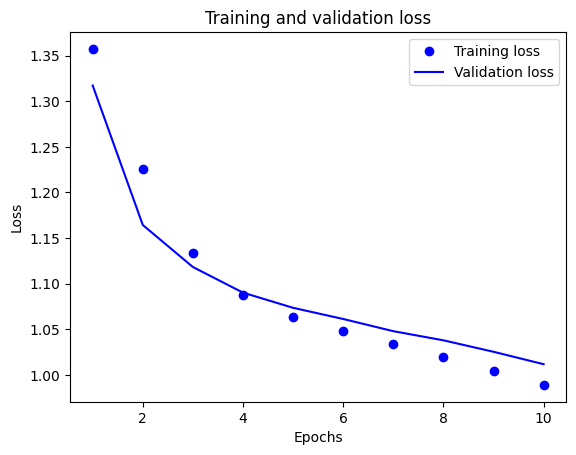

In [315]:
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

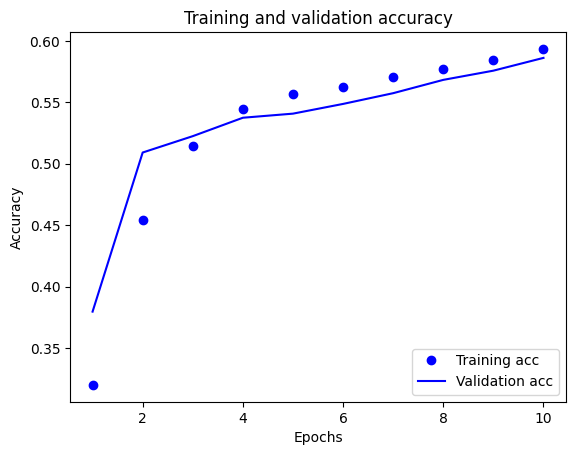

In [316]:

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()